In [2]:
df_train = pd.read_parquet('m5_train.parquet')

# Esto te imprimirá la lista exacta de las columnas que existen en tu archivo
print(df_train.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'ventas', 'd_num', 'wm_yr_wk', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'sell_price', 'snap', 'lag_7', 'lag_21', 'lag_28', 'lag_60', 'ma_7', 'ma_21', 'ma_28', 'ma_60', 'std_7', 'std_28']


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

### Carga y features

In [2]:
print("Cargando datos...")
train = pd.read_parquet('m5_train.parquet')
val   = pd.read_parquet('m5_val.parquet')

print(f"Train original: {train.shape}")
print(f"Val original:   {val.shape}")

# Definir características
features = ['lag_7', 'lag_21', 'lag_28', 'lag_60',
            'ma_7',  'ma_21',  'ma_28',  'ma_60',
            'std_7', 'std_28',
            'wday', 'month', 'snap', 'sell_price']

# Limpiar nulos generados por los rezagos (lags)
train_clean = train.dropna(subset=features)
val_clean   = val.dropna(subset=features)

# Separar X e y para el modelo único
X_train = train_clean[features]
y_train = train_clean['ventas']

X_val = val_clean[features]
y_val = val_clean['ventas']

print(f"\nTrain limpio: {train_clean.shape}")
print(f"Val limpio:   {val_clean.shape}")
print(f"% ceros en train: {(y_train == 0).mean()*100:.1f}%")

Cargando datos...
Train original: (58327370, 27)
Val original:   (853720, 27)

Train limpio: (45258166, 27)
Val limpio:   (853720, 27)
% ceros en train: 59.9%


### Entrenar modelo

In [5]:
# Configuración del modelo XGBoost Regressor
reg = xgb.XGBRegressor(
    objective='reg:squarederror', # Objetivo para regresión
    n_estimators=600,             # Número de árboles
    learning_rate=0.05,           # Tasa de aprendizaje
    max_depth=8,                  # Profundidad del árbol
    subsample=0.8,                # Muestreo de filas por árbol
    colsample_bytree=0.8,         # Muestreo de columnas por árbol
    tree_method='hist',           # Método de histograma (vital para velocidad)
    eval_metric='rmse',           # Métrica a evaluar
    random_state=42,
    n_jobs=-1
)

print("\nIniciando entrenamiento del XGBoost Regressor...")
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    #early_stopping_rounds=50,     # Se detiene si no mejora en 50 iteraciones
    verbose=50                    # Imprime progreso cada 50 árboles
)
print("Entrenamiento completado.")


Iniciando entrenamiento del XGBoost Regressor...
[0]	validation_0-rmse:4.15026	validation_1-rmse:3.51537
[50]	validation_0-rmse:2.43174	validation_1-rmse:2.00663
[100]	validation_0-rmse:2.38593	validation_1-rmse:1.98533
[150]	validation_0-rmse:2.37701	validation_1-rmse:1.98358
[200]	validation_0-rmse:2.36880	validation_1-rmse:1.98271
[250]	validation_0-rmse:2.35846	validation_1-rmse:1.98195
[300]	validation_0-rmse:2.34854	validation_1-rmse:1.98119
[350]	validation_0-rmse:2.33956	validation_1-rmse:1.98109
[400]	validation_0-rmse:2.33182	validation_1-rmse:1.98044
[450]	validation_0-rmse:2.32502	validation_1-rmse:1.98040
[500]	validation_0-rmse:2.31826	validation_1-rmse:1.97998
[550]	validation_0-rmse:2.31247	validation_1-rmse:1.97924
[599]	validation_0-rmse:2.30670	validation_1-rmse:1.97940
Entrenamiento completado.


### Prediccion y metricas

In [8]:
# Generar predicciones (se limitan a 0 porque no hay ventas negativas)
y_pred_final = np.clip(reg.predict(X_val), 0, None)

# Métricas estándar
mae  = mean_absolute_error(y_val, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_final))

# Función rápida para aproximar WRMSSE a nivel de item
def calcular_wrmsse_rapido(y_pred, val_clean, train_clean):
    df_val = val_clean[['id', 'ventas']].copy()
    df_val['pred'] = y_pred

    err = df_val.groupby('id').apply(
        lambda x: np.mean((x['ventas'].values - x['pred'].values) ** 2)
    ).reset_index(name='mse')

    escala = train_clean.groupby('id')['ventas'].apply(
        lambda x: np.mean(np.diff(x.values) ** 2)
    ).reset_index(name='escala')

    peso = train_clean.groupby('id')['ventas'].sum().reset_index(name='peso')

    df_m = err.merge(escala, on='id').merge(peso, on='id')
    df_m = df_m[df_m['escala'] > 0]

    return np.sqrt(np.average(df_m['mse'] / df_m['escala'], weights=df_m['peso']))

print("\nCalculando WRMSSE...")
wrmsse_score = calcular_wrmsse_rapido(y_pred_final, val_clean, train_clean)

print("=" * 45)
print("       RESULTADOS DEL MODELO XGBOOST")
print("=" * 45)
print(f"  MAE                   : {mae:.4f}")
print(f"  RMSE                  : {rmse:.4f}")
print(f"  WRMSSE                : {wrmsse_score:.4f}")
print("=" * 45)


Calculando WRMSSE...
       RESULTADOS DEL MODELO XGBOOST
  MAE                   : 0.9947
  RMSE                  : 1.9794
  WRMSSE                : 0.7485


### Revisar sobreajuste

In [9]:
# Predecir en train para comparar
y_pred_train = np.clip(reg.predict(X_train), 0, None)

mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("=" * 45)
print("   VERIFICACIÓN DE SOBREAJUSTE")
print("=" * 45)
print(f"{'Métrica':<10} {'Train':>10} {'Val':>10} {'Diferencia':>12}")
print("-" * 45)
print(f"{'MAE':<10} {mae_train:>10.4f} {mae:>10.4f} {abs(mae_train-mae):>12.4f}")
print(f"{'RMSE':<10} {rmse_train:>10.4f} {rmse:>10.4f} {abs(rmse_train-rmse):>12.4f}")
print("=" * 45)

   VERIFICACIÓN DE SOBREAJUSTE
Métrica         Train        Val   Diferencia
---------------------------------------------
MAE            0.9786     0.9947       0.0161
RMSE           2.3066     1.9794       0.3273


### Curvas de aprendizaje

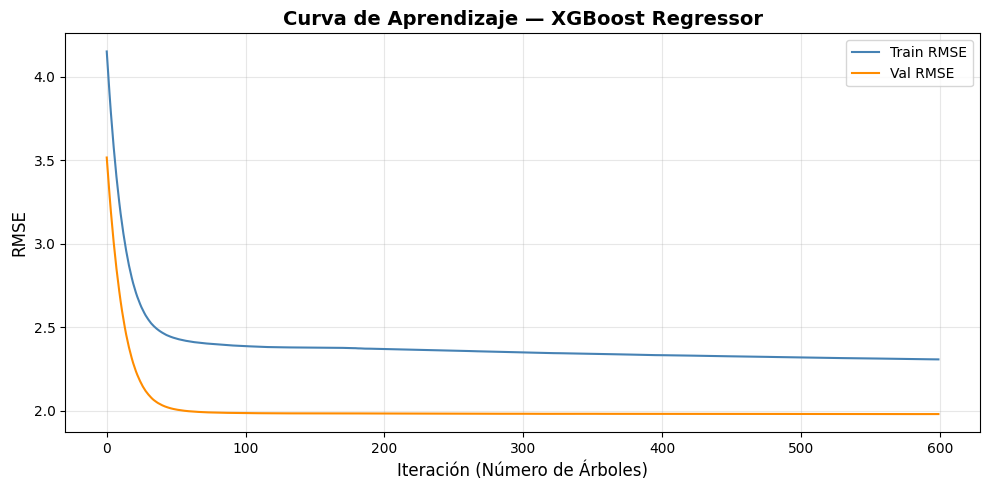

In [10]:
# Extraer resultados de evaluación de XGBoost
resultados = reg.evals_result()

plt.figure(figsize=(10, 5))
# validation_0 es Train, validation_1 es Val
plt.plot(resultados['validation_0']['rmse'], label='Train RMSE', color='steelblue')
plt.plot(resultados['validation_1']['rmse'], label='Val RMSE', color='darkorange')

plt.title('Curva de Aprendizaje — XGBoost Regressor', fontsize=14, fontweight='bold')
plt.xlabel('Iteración (Número de Árboles)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Resultados e importancia de valores

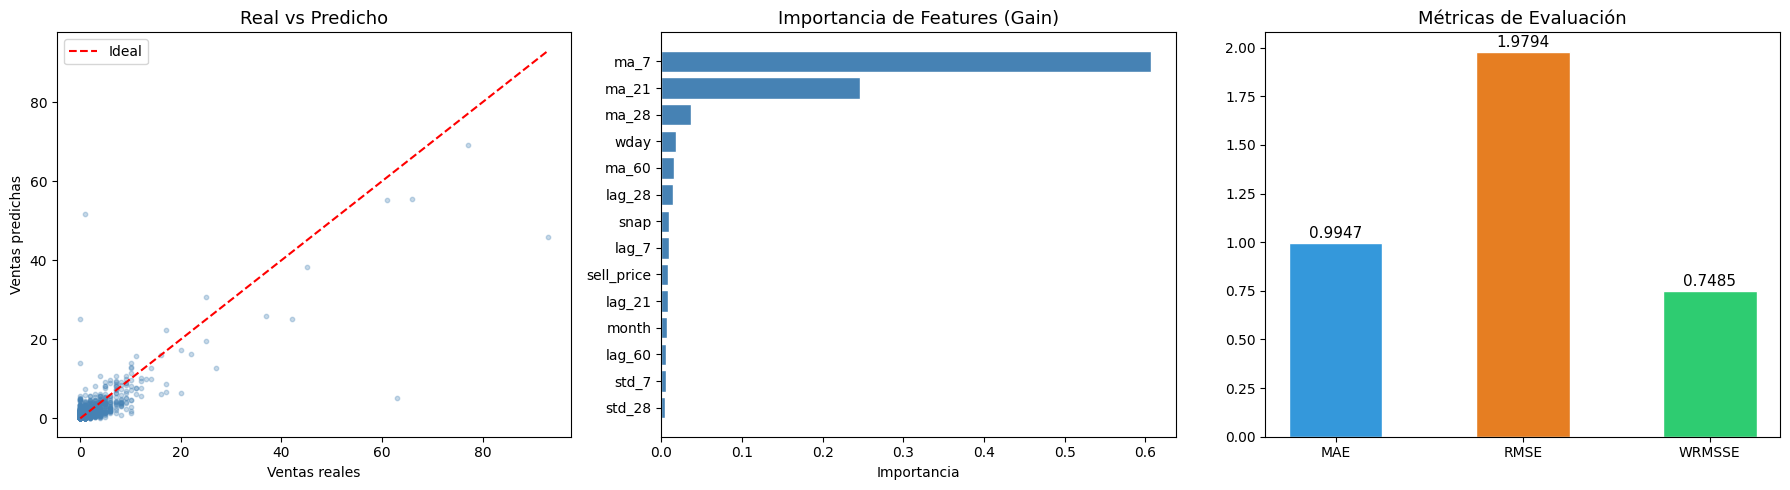

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Real vs Predicho (Muestra de 2000 puntos para que se entienda)
sample = np.random.choice(len(y_val), size=2000, replace=False)
axes[0].scatter(y_val.values[sample], y_pred_final[sample], alpha=0.3, s=10, color='steelblue')
max_val = max(y_val.values[sample].max(), y_pred_final[sample].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ideal')
axes[0].set_title('Real vs Predicho', fontsize=13)
axes[0].set_xlabel('Ventas reales')
axes[0].set_ylabel('Ventas predichas')
axes[0].legend()

# 2. Importancia de features de XGBoost
importancia = pd.DataFrame({
    'feature': features,
    'importance': reg.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importancia['feature'], importancia['importance'], color='steelblue', edgecolor='white')
axes[1].set_title('Importancia de Features (Gain)', fontsize=13)
axes[1].set_xlabel('Importancia')

# 3. Métricas resumen
metricas = ['MAE', 'RMSE', 'WRMSSE']
valores  = [mae, rmse, wrmsse_score]
colores  = ['#3498db', '#e67e22', '#2ecc71']
bars = axes[2].bar(metricas, valores, color=colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, valores):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
    
axes[2].set_title('Métricas de Evaluación', fontsize=13)
plt.tight_layout()
plt.show()

### Guardar el modelo

In [12]:
os.makedirs('modelos', exist_ok=True)
ruta_modelo = 'modelos/regresor_xgboost_unico.pkl'

joblib.dump(reg, ruta_modelo)

print(f"Modelo guardado exitosamente en: {ruta_modelo}")
print("Para cargarlo después utiliza: reg = joblib.load('modelos/regresor_xgboost_unico.pkl')")

Modelo guardado exitosamente en: modelos/regresor_xgboost_unico.pkl
Para cargarlo después utiliza: reg = joblib.load('modelos/regresor_xgboost_unico.pkl')
